# **Skip-gram model**
## **Sliding context window (window size = 2)**

<img src="https://drive.google.com/uc?id=12lqDCHXKSx1wcri51Z8jG2JZeU8Wg5tG">
<br>

## **Trainning**
<img src="https://drive.google.com/uc?id=1x_o6BUUxbF_mX3rUKgzfWFzLqoUVmohD"> <br>
<div style="text-align: right"> source: <a href=http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/> http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/ </a> </div>

# **CBOW vs Skip-gram**
<font size="3">
<br>
<b>CBOW:</b> The input to the model could be w<sub>i−2</sub>,w<sub>i−1</sub>,w<sub>i+1</sub>,w<sub>i+2</sub>, the preceding and following words of the current word we are at.<br> The output of the neural network will be w<sub>i</sub>. Hence you can think of the task as <i>"predicting the word given its context."</i>
<br>
<b>Skip-gram:</b> The input to the model is w<sub>i</sub>, and the output could be w<sub>i−2</sub>,w<sub>i−1</sub>,w<sub>i+1</sub>,w<sub>i+2</sub>. So the task here is  <i>"predicting the context <br>given a word." </i>
<br>   
According to Mikolov:
<br>
Skip-gram: works well with small amount of the training data, represents well even rare words or phrases.
<br>
CBOW: several times faster to train than the skip-gram, slightly better accuracy for the frequent words
</font>

## **Install Gensim**

In [1]:
!pip install --upgrade gensim

     |████████████████████████████████| 24.2MB 167kB/s 
  Found existing installation: gensim 3.6.0
    Uninstalling gensim-3.6.0:
      Successfully uninstalled gensim-3.6.0


## **Download, unzip & load Google news embeddings**

In [2]:
!wget https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz

--2020-05-03 18:29:13--  https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.146.93
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.146.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1647046227 (1.5G) [application/x-gzip]
Saving to: ‘GoogleNews-vectors-negative300.bin.gz’

GoogleNews-vectors- 100%[===================>]   1.53G  81.6MB/s    in 20s     

2020-05-03 18:29:33 (76.9 MB/s) - ‘GoogleNews-vectors-negative300.bin.gz’ saved [1647046227/1647046227]



In [0]:
!gzip -d GoogleNews-vectors-negative300.bin.gz

In [0]:
from gensim.models import KeyedVectors
filename = 'GoogleNews-vectors-negative300.bin'
model = KeyedVectors.load_word2vec_format(filename, binary=True)

## **Calculate and visualize distances between relevant words**

In [5]:
# calculate: (king - man) + woman = ?
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(result)

[('queen', 0.7118192911148071)]


In [6]:
# body parts
result = model.most_similar(positive=['leg','hand'], topn=5)
print(result)

[('forearm', 0.6304388642311096), ('arm', 0.6039904356002808), ('thigh', 0.6026855707168579), ('shoulder', 0.5886558890342712), ('finger', 0.5883219242095947)]


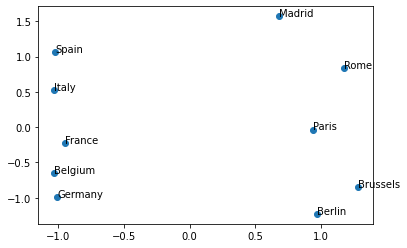

In [7]:
%matplotlib inline
from sklearn.decomposition import PCA
from matplotlib import pyplot
import numpy as np

Countries_Capitals = ["Germany","France","Italy","Spain","Belgium","Berlin","Paris","Rome","Madrid","Brussels"]

vecs = []
for cc in Countries_Capitals:
    vecs.append(model[cc])
    
vecs = np.stack(vecs, axis=0)

# fit a 2d PCA model to the vectors
pca = PCA(n_components=2)
result = pca.fit_transform(vecs)
# # create a scatter plot of the projection
pyplot.scatter(result[:, 0], result[:, 1])
words = Countries_Capitals
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

## **Train w2v on a custom corpus**

In [8]:
from gensim.models import Word2Vec
# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
['this', 'is', 'the', 'second', 'sentence'],
['yet', 'another', 'sentence'],
['one', 'more', 'sentence'],
['and', 'the', 'final', 'sentence']]

# train model
t_model = Word2Vec(sentences, min_count=1)
# summarize the loaded model
print(model)
# summarize vocabulary
words = list(t_model.wv.vocab)
print(words)
# access vector for one word
print(t_model.wv.__getitem__('sentence'))
# save model
t_model.save('model.bin')
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec', 'second', 'yet', 'another', 'one', 'more', 'and', 'final']
[-0.0004153  -0.0019186   0.00357682 -0.00042974  0.00025563 -0.00199623
  0.00103021  0.00349546 -0.0019219  -0.00118455  0.00168632  0.00318399
  0.00181872  0.00248991 -0.00270604 -0.00079849 -0.0034359   0.00201052
 -0.00057361 -0.00090507 -0.00371562 -0.00237907  0.00316327 -0.0015906
  0.00419607  0.00499477 -0.00471419  0.00357136 -0.00159271 -0.00215587
  0.00460764  0.00284183  0.00467266  0.0020416  -0.00208638 -0.00142645
 -0.00065399 -0.00430011 -0.00309491  0.00141496 -0.00281872 -0.00337944
  0.00130562  0.00306717  0.00084441 -0.00110997  0.00088903 -0.00202561
 -0.00280106 -0.0009176  -0.00385016  0.0040641  -0.00189844 -0.00440304
 -0.00016998 -0.00447879 -0.00314507  0.0023472   0.00234952  0.00168019
 -0.00309217 -0.00198599 -0.0043071  -0.00075723  0.0027179   0.00101251
 -0.00433223 -0.00135574  0.00256049  0.00367225 -0.00049206 -0.00048577
  0.

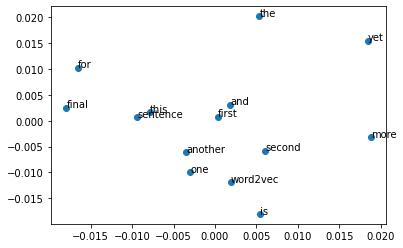

In [9]:
%matplotlib inline
from sklearn.decomposition import PCA
from matplotlib import pyplot

# fit a 2d PCA model to the vectors
X = new_model.wv.vectors
pca = PCA(n_components=2)
result = pca.fit_transform(X)
# create a scatter plot of the projection
pyplot.scatter(result[:, 0], result[:, 1])
words = list(new_model.wv.vocab)
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

## **References**
* https://radimrehurek.com/gensim/tutorial.html
* https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
* http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/
* https://www.quora.com/What-are-the-continuous-bag-of-words-and-skip-gram-architectures